# Obiettivi del Progetto  

1. Addestrare un classificatore per identificare le email SPAM.
2. Individuare i Topic principali tra le email classificate come SPAM.
3. Calcolare la distanza semantica tra i topics ottenuti per valutare l'eterogeneità dei contenuti delle email SPAM.
4. Estrarre dalle email NON SPAM le informazioni sulle Organizzazioni menzionate.

## Import and setup

In [1]:
# Installation libraries
%pip install gensim pyLDAVis wordcloud

import os
import re
import string
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# NLP & Preprocessing
import nltk
from nltk.corpus import stopwords
import spacy

# Deep Learning
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Embedding, Dense, Dropout
from tensorflow.keras.metrics import AUC

# Topic Modeling
import gensim
import gensim.downloader
from gensim import corpora

# Similarity
from scipy.spatial.distance import cosine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 35.1 MB/s eta 0:00:00


In [2]:
# Say NO to warnings!
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel("ERROR")

In [3]:
RANDOM_SEED = 16
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [4]:
# NLTK Setup
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words("english"))

domain_stopwords = {
    "subject", "http", "am", "pm",
    "na", "cc", "fw", "re"
}
stop_words.update(domain_stopwords)

# SpaCy model
# !python -m spacy download en_core_web_lg
nlp = spacy.load("en_core_web_lg")

# GloVe model
glove_model = gensim.downloader.load("glove-wiki-gigaword-300")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
[==================================================] 100.0% 376.1/376.1MB downloaded


## Functions

### EDA Functions

In [5]:
def mean_word_length(df):
    """ Function to analyze the length of mails in terms of word count, separating "ham" and "spam" mails """

    data = df.copy()
    data["mail_length"] = data["text"].astype(str).apply(lambda x: len(x.split()))

    subsets = [
        ("All Mails", data),
        ("Ham", data[data["label_num"] == 0]),
        ("Spam", data[data["label_num"] == 1])
    ]

    colors = sns.color_palette("tab10", len(subsets))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, (title, subset) in enumerate(subsets):
        sns.histplot(
            subset["mail_length"],
            bins=40,
            kde=True,
            color=colors[i],
            ax=axes[i]
        )
        axes[i].set_title(title, fontsize=14)
        axes[i].set_xlabel("Words per mail")
        axes[i].set_ylabel("Frequency")

    fig.suptitle("Word Count Distribution in Mails", fontsize=18, y=1.03)
    plt.tight_layout()

In [6]:
def wordcloud_spam(df):
    """ Generate a wordcloud of spam mails """

    spam_mail = df[df["label_num"] == 1]["text"].dropna().astype(str)

    wc = WordCloud(
        width=800, height=400,
        background_color="black",
        max_words=200
    ).generate(" ".join(spam_mail))

    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud - Spam Mails", fontsize=12)
    plt.tight_layout()
    plt.show()

### Data Cleaning Functions

In [7]:
def strip_email(text):
    """ Extracts and normalizes the main body of text content from emails """
    if text is None:
        return ""
    text = str(text)

    # 1. Find the first occurrence of "subject :"
    m_subj = re.search(r"subject\s*:", text, flags=re.IGNORECASE)

    if m_subj:
        body = text[m_subj.start():]
    else:
        body = text

    # 2. Remove block between "to : and "subject :"
    body = re.sub(
        r"(?is)to\s*:.*?(?=subject\s*:)",
        "",
        body
    )

    # 3. Delete everything from "forwarded by" onwards
    m_fwd = re.search(r"forwarded by", body, flags=re.IGNORECASE)
    if m_fwd:
        body = body[:m_fwd.start()]

    return body.strip()

In [8]:
def data_cleaner(text):
    """
    Performs full text preprocessing:
      - lowercase
      - remove HTML tags, URL, digits, punctuation
      - normalize repeated letters
      - remove extra whitespaces
      - tokenize, stopwords removal, lemmatization
    """
    if text is None:
        return ""
    text = str(text)

    # 0. Email structural cleanup
    text = strip_email(text)

    # 1. Lowercase
    text = text.lower()

    # 2. Remove HTML
    text = re.sub(r"<.*?>", "", text)

    # 3. Remove URLs and emails
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", "", text)

    # 4. Remove numbers
    text = re.sub(r"\d+", "", text)

    # 5. Normalize whitespace
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()

    # 6. Normalize repeated letters
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # SpaCy processing
    doc = nlp(text)

    cleaned_tokens = []
    for token in doc:
        # Skip spaces and punctuation
        if token.is_space or token.is_punct:
            continue

        base = token.lemma_.lower().strip()

        # Stopwords
        if token.is_stop or base in stop_words:
            continue

        # Skip short token
        if len(base) <= 1:
            continue

        cleaned_tokens.append(base)

    return " ".join(cleaned_tokens)

In [9]:
def topic_cleaner(text):
    """ Preprocessing for topic modeling / LDA """
    if text is None:
        return []
    text = str(text)

    # 0. Email structural cleanup
    text = strip_email(text)

    # 1. Lowercase
    text = text.lower()

    # 2. Remove HTML
    text = re.sub(r"<.*?>", "", text)

    # 3. Remove URLs and emails
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", "", text)

    # 4. Remove numbers
    text = re.sub(r"\d+", "", text)

    # 5. Normalize whitespace
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()

    # 6. Normalize repeated letters
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # SpaCy processing
    doc = nlp(text)

    tokens = []
    for token in doc:
        # Skip spaces and punctuation
        if token.is_space or token.is_punct:
            continue

        # Keep only alphabetic tokens
        if not token.is_alpha:
            continue

        lemma = token.lemma_.lower().strip()

        # Stopwords
        if token.is_stop or lemma in stop_words:
            continue

        # Skip short strings
        if len(lemma) < 3:
            continue

        tokens.append(lemma)

    return tokens

In [10]:
def ner_cleaner(text):
    """ Text normalization for NER tasks. """
    if text is None:
        return ""
    text = str(text)

    # 1. Remove URLs ed emails
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", "", text)

    # 2. Remove numbers ONLY if isolated
    text = re.sub(r"\b\d+\b", " ", text)

    # 3. Normalize whitespace
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()

    # 4. Remove punctuation except "&"
    punc = string.punctuation.replace("&", "")
    text = text.translate(str.maketrans("", "", punc))

    return text

### Text Vectorization Function

In [11]:
def bow_tfidf(dataset, vectorizer=None, min_df=1, max_df=1.0, ngram_range=(1,1)):
    """ Performs Fit+Transform using TF-IDF """

    if vectorizer is not None:
        X = vectorizer.transform(dataset)
        return X.toarray(), vectorizer

    vectorizer = TfidfVectorizer(
        min_df=min_df,
        max_df=max_df,
        ngram_range=ngram_range,
        strip_accents="unicode",
        sublinear_tf=True
    )
    X = vectorizer.fit_transform(dataset)

    return X.toarray(), vectorizer

### Validation Function

In [12]:
def classification_report_function(model, X_train, y_train, X_test, y_test,
    threshold=0.5, NN=False, labels=("HAM", "SPAM"), show_plots=True,
):
    """ Print classification reports, AUC and confusion matrices for train/test """

    # Prediction
    if NN:
        y_score_train = np.ravel(model.predict(X_train))
        y_score_test = np.ravel(model.predict(X_test))
    else:
        y_score_train = model.predict_proba(X_train)[:, 1]
        y_score_test = model.predict_proba(X_test)[:, 1]

    y_pred_train = (y_score_train >= threshold).astype(int)
    y_pred_test = (y_score_test >= threshold).astype(int)

    def _print_and_plot(split_name, y_true, y_pred, y_score=None):
        print(f"Classification report for {split_name}:")
        print("-" * 43)
        print(classification_report(y_true, y_pred, target_names=list(labels)))

        # AUC
        if y_score is not None:
            try:
                roc_auc = roc_auc_score(y_true, y_score)
                print(f"AUC-ROC Score: {roc_auc:.3f}")
            except ValueError:
                pass

        # Confusion matrix
        if show_plots:
            cm = confusion_matrix(y_true, y_pred)
            plt.figure(figsize=(5, 4))
            sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=labels,
                yticklabels=labels,
            )
            plt.xlabel("Predicted")
            plt.ylabel("True")
            plt.title(f"Confusion Matrix ({split_name})")
            plt.tight_layout()
            plt.show()

        print()

    # Train
    _print_and_plot(
        "training",
        y_train,
        y_pred_train,
        None if NN else y_score_train
    )

    print("-" * 43)

    # Test
    _print_and_plot(
        "testing",
        y_test,
        y_pred_test,
        None if NN else y_score_test
    )

### Topic Modeling Representations

In [13]:
def avg_topic_vector(topic_words, embedding_model):
    """ Calculate the mean vector for a topic using an embedding model """
    if topic_words is None:
        return np.zeros(embedding_model.vector_size)

    vectors = []

    for word in topic_words:
        if word in embedding_model:
            vectors.append(embedding_model.get_vector(word))

    if not vectors:
        return np.zeros(embedding_model.vector_size)

    return np.mean(vectors, axis=0)

## Dataset

In [14]:
BASE_URL = "https://raw.githubusercontent.com/ProfAI/natural-language-processing/refs/heads/main/datasets/Verifica%20Finale%20-%20Spam%20Detection/"
df = pd.read_csv(BASE_URL + "spam_dataset.csv")

In [15]:
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


Il dataset contiene 5.171 record e 4 variabili: due numeriche di tipo intero (*Unnamed: 0* e *label_num*) e due variabili testuali di tipo stringa (*label* e *text*).

## EDA

In [17]:
print("Missing values: \n", df.isnull().sum())
print(f"\nDuplicates: {df.duplicated().sum()}")

Missing values: 
 Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64

Duplicates: 0


All'interno del dataset non sono presenti né valori mancanti né duplicati.

In [18]:
print(f"Values in Unnamed: 0 = {len(df["Unnamed: 0"])}")

print(f"\nValues in label = {set(df["label"])}")
print(f"Values in label_num = {set(df["label_num"])}")

Values in Unnamed: 0 = 5171

Values in label = {'spam', 'ham'}
Values in label_num = {0, 1}


La variabile *Unnamed: 0* contiene 5.171 valori e quindi potrebbe trattarsi i un semplice indice numerico.

La variabile *label* invece presenta due categorie: "ham" e "spam", corrispondenti alle classi del problema di classificazione mentre *label_num* ne rappresenta la codifica binaria.

In [19]:
# Filter indexes of the "spam" class
spam_index = df.loc[df["label"] == "spam", "Unnamed: 0"]

print(f"Spam items: {spam_index.size}")
print(f"Min index: {spam_index.min()}")
print(f"Max index: {spam_index.max()}")

Spam items: 1499
Min index: 3672
Max index: 5170


La variabile "Unnamed: 0", considerata solo per le mail classificate come spam (1499 osservazioni), assume gli ultimi 1499 valori compresi nell’intervallo fino a 5170. Si potrebbe trattare quindi di un indice derivante da un ordinamento precedente, nel quale i messaggi di spam venivano collocati dopo quelli classificati come ham.

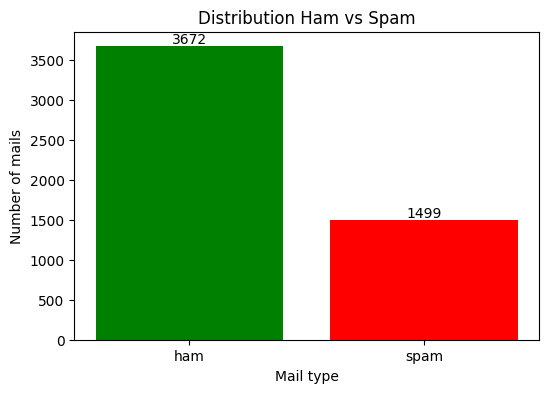


Spam Mails: 1499 (28.99%)


In [20]:
# Dataset balancing
label_counts = df["label_num"].value_counts()
labels = ["ham", "spam"]
values = [label_counts.get(0, 0), label_counts.get(1, 0)]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=["green", "red"])
plt.xlabel("Mail type")
plt.ylabel("Number of mails")
plt.title("Distribution Ham vs Spam")

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{value}", ha="center", va="bottom")

plt.show()

percent_spam = values[1] / sum(values) * 100
print(f"\nSpam Mails: {values[1]} ({percent_spam:.2f}%)")

Possiamo notare una marcata asimmetria tra le due classi: le mail spam sono 1.499, pari al 28,99% del totale, e rappresentato quindi una minoranza significativa all’interno del dataset.

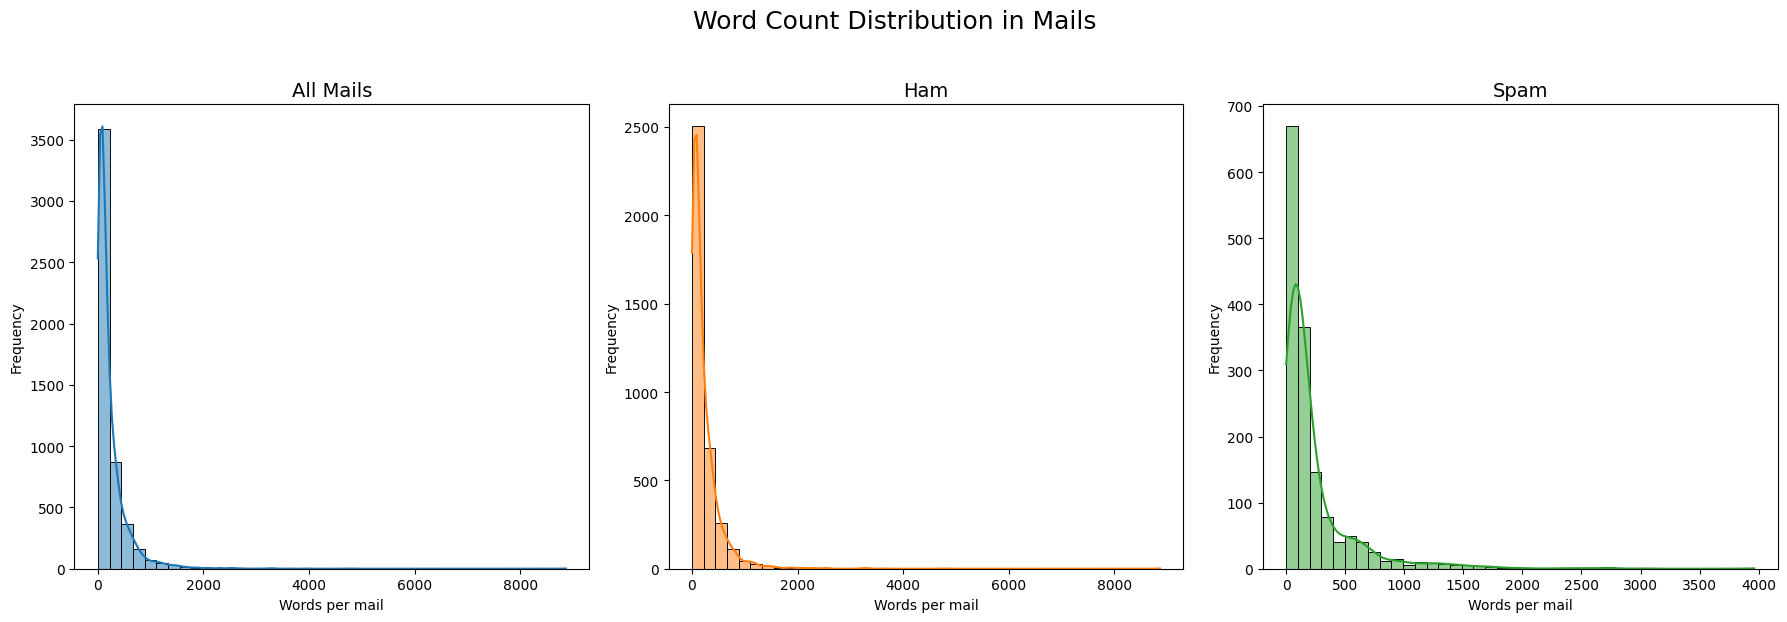

In [21]:
mean_word_length(df)

Il grafico mostra la distribuzione della lunghezza dei messaggi per l’intero dataset e separatamente per le classi ham e spam.

In tutti i casi la distribuzione è fortemente asimmetrica verso destra: la maggior parte delle mail contiene poche parole, mentre un numero limitato di messaggi presenta lunghezze molto elevate. Possiamo inoltre osservare come le mail spam tendono a essere mediamente più brevi delle mail ham.

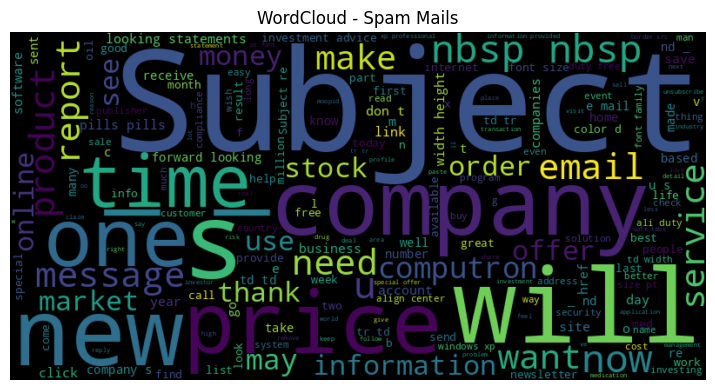

In [22]:
wordcloud_spam(df)

Il wordcloud evidenzia le parole più frequenti nelle mail spam, dominate da termini come: *subject*, *company*, *price*, *will* e *time*. Queste ricorrenze indicano contenuti tipici legati a offerte commerciali, promozioni e messaggi generici pensati per attirare l’attenzione del destinatario.

## Text Cleaning & Preprocessing

Procediamo separando il dataset in features (X) e target (y).

In [23]:
X = df["text"]
y = df["label_num"]

In [24]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5171,)
y shape: (5171,)


In [25]:
X_cleaned = X.apply(data_cleaner)

Con la funzione **data_cleaner()** esegue una pulizia completa del testo: elimina elementi superflui (HTML, URL, numeri, punteggiatura), normalizza gli spazi, poi applica tokenizzazione, rimozione delle stopword e lemmatizzazione, producendo un testo pronto per l’analisi.

In [26]:
print("Preprocessing example:\n")
print("Original: \n", X.iloc[RANDOM_SEED])
print("\nCleaned:\n", X_cleaned.iloc[RANDOM_SEED])

Preprocessing example:

Original: 
 Subject: re : first delivery - wheeler operating
vance ,
deal # 643714 has been created and entered in sitara .
bob
vance l taylor
02 / 23 / 2001 04 : 55 pm
to : robert cotten / hou / ect @ ect
cc : julie meyers / hou / ect @ ect , lisa hesse / hou / ect @ ect , cynthia
hakemack / hou / ect @ ect , susan smith / hou / ect @ ect , donald p
reinhardt / hou / ect @ ect , melissa graves / hou / ect @ ect
subject : first delivery - wheeler operating
bob ,
the following production is now on - line and a ticket should be created and
entered into sitara based on the following :
counterparty meter volumes price period global no .
wheeler operating 9879 800 mmbtu / d 85 % gas daily 2 / 17 - 2 / 28 nya
fyi , i have created and submitted a committed reserves firm ticket for the
remaining term of the deal beginning with the month of march . additionally ,
this is a producer svcs . deal and should be tracked in the im wellhead
portfolio . . . attached to the gathe

Suddividiamo il dataset in training e test set utilizzando stratify per preservare la proporzione di mail spam, dato lo sbilanciamento delle classi, e impostando un random_state per garantire la replicabilità dei risultati.

In [27]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

print(f"Shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Shape: X_test={X_test.shape}, y_test={y_test.shape}")

Shape: X_train=(4136,), y_train=(4136,)
Shape: X_test=(1035,), y_test=(1035,)


Procediamo ora con la fase di vettorizzazione, applicando il fit esclusivamente sul training set e utilizzando il vettorizzatore così ottenuto per trasformare i dati di test.

In [28]:
# Vectorization
X_train_tfidf, vect = bow_tfidf(X_train, min_df=0.01, max_df=0.9)
X_test_tfidf, _ = bow_tfidf(X_test, vect)

print(f"Shape: X_train_tfidf= {X_train.shape}")
print(f"Shape: X_test_tfidf= {X_test.shape}")

Shape: X_train_tfidf= (4136,)
Shape: X_test_tfidf= (1035,)


In questa fase utilizziamo una vettorizzazione TF-IDF perchè andremo inizialmente a sviluppare un modello Naive Bayes, successivamente ricorreremo a tecniche basate su embedding per l'addestramento di una rete neurale.

## Model

### Naive-Bayes

Iniziamo con un modello ML come il Multinomial Naive-Bayes utilizzato sul testo vettorizzato tramite Tf-Idf

In [29]:
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

Valutiamo le prestazioni del modello su entrambi i set, considerando tutte le metriche ma ponendo particolare attenzione alla *precision*, poiché è fondamentale evitare che mail ham vengano classificate come spam. Perciò adottiamo una threshold superiore al valore predefinito di 0,5.

Classification report for training:
-------------------------------------------
              precision    recall  f1-score   support

         HAM       0.94      0.96      0.95      2937
        SPAM       0.90      0.84      0.87      1199

    accuracy                           0.93      4136
   macro avg       0.92      0.90      0.91      4136
weighted avg       0.93      0.93      0.93      4136

AUC-ROC Score: 0.981


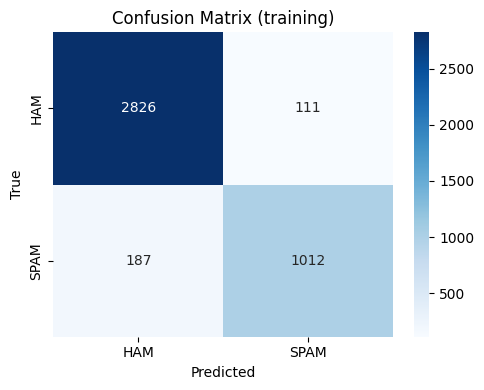


-------------------------------------------
Classification report for testing:
-------------------------------------------
              precision    recall  f1-score   support

         HAM       0.94      0.96      0.95       735
        SPAM       0.89      0.86      0.88       300

    accuracy                           0.93      1035
   macro avg       0.92      0.91      0.91      1035
weighted avg       0.93      0.93      0.93      1035

AUC-ROC Score: 0.984


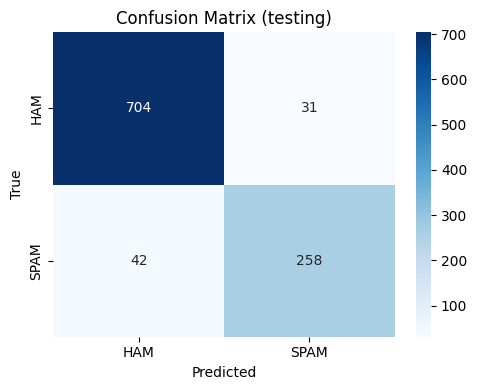

In [30]:
classification_report_function(nb_model, X_train_tfidf, y_train, X_test_tfidf, y_test, threshold=0.7)

Il modello raggiunge un’accuratezza del 93% nel training set, con una buona capacità di distinguere tra HAM e SPAM: la precision per lo SPAM è pari a 0.90, mentre il recall è pari a 0.84, indicando qualche errore nel riconoscere tutti i messaggi spam ma un rischio moderato di falsi positivi. L’AUC-ROC di 0.98 conferma un’eccellente capacità discriminativa.

Le prestazioni si rimangono pressoché invariate nel testing set, con un’accuratezza ancora del 93% e metriche molto simili al training. Questo suggerisce che il modello generalizza bene e non mostra segni significativi di overfitting.

Il modello risulta quindi affidabile e bilanciato nelle sue prestazioni, con una forte capacità di discriminazione tra le due classi.

Verifichiamo ora, tramite una ricerca con *RandomizedSearch*, se è possibile migliorare il modello ottimizzando gli iperparametri della fase di vettorizzazione.


In [31]:
base_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", MultinomialNB())
])

param_dist = {
    "tfidf__max_df": [0.7, 0.85, 0.95],         # ignore frequent words
    "tfidf__min_df": [1, 2, 5, 10],             # ignore rare rarewords
    "tfidf__ngram_range": [(1,1), (1,2)],       # unigrams vs unigrams+bigrams
    "tfidf__max_features": [ 2000, 5000, None]  # vocab size
}

In [32]:
random_search = RandomizedSearchCV(
    estimator=base_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    scoring="f1_macro",
    verbose=2,
    n_jobs=-1,
    random_state=RANDOM_SEED
)
random_search.fit(X_train, y_train)

best_params = random_search.best_params_

print("\nBest parameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

print(f"\nBest CV score ({random_search.scoring}): {random_search.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best parameters:
  tfidf__ngram_range: (1, 2)
  tfidf__min_df: 1
  tfidf__max_features: 5000
  tfidf__max_df: 0.85

Best CV score (f1_macro): 0.9518


La ricerca degli iperparametri individua come migliore configurazione un modello basato su unigrammi e bigrammi (ngram_range = (1, 2)), senza esclusione dei termini rari (min_df = 1) e con un limite massimo di 5.000 feature. Inoltre, vengono filtrati i termini eccessivamente frequenti attraverso un valore di max_df pari a 0.85.

Il punteggio di cross-validation ottenuto (f1_macro = 0.9518) risulta superiore rispetto al modello iniziale, indicando un miglioramento complessivo della capacità di generalizzazione.

In [33]:
# Initializes TF-IDF with the best parameters found by RandomizedSearch
best_tfidf = TfidfVectorizer(
    max_df=best_params["tfidf__max_df"],
    min_df=best_params["tfidf__min_df"],
    ngram_range=best_params["tfidf__ngram_range"],
    max_features=best_params["tfidf__max_features"],
)

X_train_tfidf_best = best_tfidf.fit_transform(X_train)
X_test_tfidf_best = best_tfidf.transform(X_test)

nb_best_model = MultinomialNB()
nb_best_model.fit(X_train_tfidf_best, y_train)

MultinomialNB()

Classification report for training:
-------------------------------------------
              precision    recall  f1-score   support

         HAM       0.96      0.99      0.97      2937
        SPAM       0.97      0.90      0.93      1199

    accuracy                           0.96      4136
   macro avg       0.96      0.95      0.95      4136
weighted avg       0.96      0.96      0.96      4136

AUC-ROC Score: 0.995


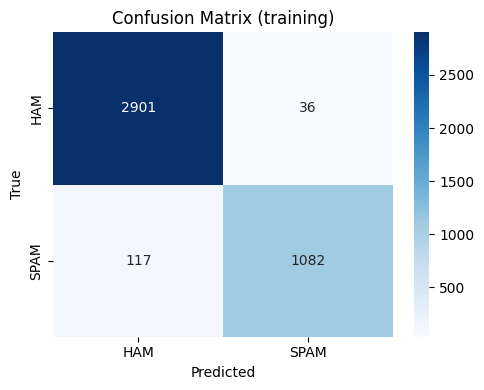


-------------------------------------------
Classification report for testing:
-------------------------------------------
              precision    recall  f1-score   support

         HAM       0.96      0.99      0.97       735
        SPAM       0.96      0.90      0.93       300

    accuracy                           0.96      1035
   macro avg       0.96      0.94      0.95      1035
weighted avg       0.96      0.96      0.96      1035

AUC-ROC Score: 0.995


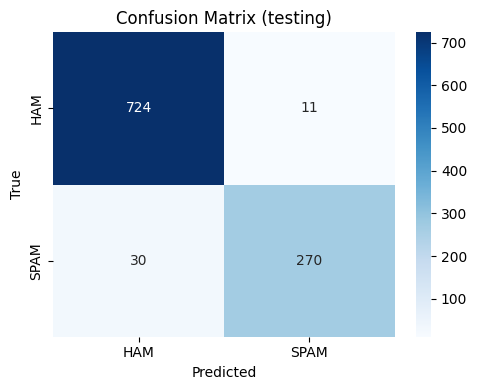

In [34]:
classification_report_function(nb_best_model, X_train_tfidf_best, y_train, X_test_tfidf_best, y_test, threshold=0.7)

Il nuovo modello mostra un miglioramento netto rispetto alla versione precedente. L’accuratezza sale al 96% sia sul training set sia sul testing set, con una riduzione significativa sia dei falsi positivi sia dei falsi negativi. Le metriche relative alla classe SPAM migliorano in modo consistente, soprattutto in termini di precision e recall. L’AUC-ROC, pari a 0.995 in entrambi i set, conferma un’eccellente capacità discriminativa.

### MultiLayer Perceptron

Per il MultiLayer Perceptron utilizziamo la stessa vettorizzazione adottata in precedenza per il modello Naive Bayes.

In [35]:
X_train_tfidf_array = X_train_tfidf_best.toarray()
X_test_tfidf_array = X_test_tfidf_best.toarray()

In [36]:
# Callback for early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [37]:
mlp_model = Sequential([
    Dense(512, activation="relu", input_shape=(X_train_tfidf_array.shape[1],)),
    Dropout(0.3),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", "Precision"])

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     2,560,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,692,097 (10.27 MB)

 Trainable params: 2,692,097 (10.27 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
%%time
mlp_history = mlp_model.fit(
    X_train_tfidf_array,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_tfidf_array, y_test),
    callbacks=early_stopping,
    verbose=1
)

Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - Precision: 0.9712 - accuracy: 0.8232 - loss: 0.3612 - val_Precision: 0.9389 - val_accuracy: 0.9739 - val_loss: 0.0655
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.9616 - accuracy: 0.9855 - loss: 0.0377 - val_Precision: 0.9510 - val_accuracy: 0.9768 - val_loss: 0.0623
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.9915 - accuracy: 0.9972 - loss: 0.0096 - val_Precision: 0.9513 - val_accuracy: 0.9787 - val_loss: 0.0661
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Precision: 0.9936 - accuracy: 0.9977 - loss: 0.0059 - val_Precision: 0.9513 - val_accuracy: 0.9787 - val_loss: 0.0690
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Precision: 0.9924 - accuracy: 0.9972 - loss: 0.0059 - val_Precision: 0.9484 - val_accuracy: 0.9787 - val_loss: 0.0726
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Precision: 0.9928 - accuracy: 0.9971 - loss: 0.0059 - val_Precision: 0.9515 - val_acc

130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Classification report for training:
-------------------------------------------
              precision    recall  f1-score   support

         HAM       1.00      1.00      1.00      2937
        SPAM       0.99      1.00      1.00      1199

    accuracy                           1.00      4136
   macro avg       1.00      1.00      1.00      4136
weighted avg       1.00      1.00      1.00      4136



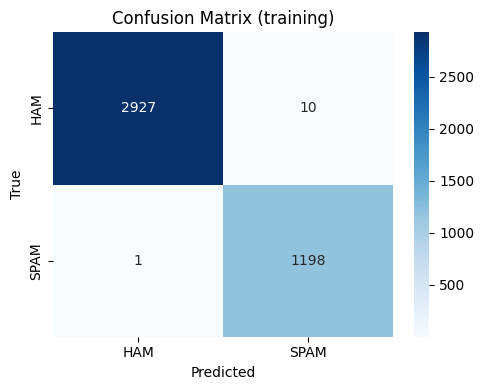


-------------------------------------------
Classification report for testing:
-------------------------------------------
              precision    recall  f1-score   support

         HAM       0.99      0.98      0.99       735
        SPAM       0.96      0.97      0.97       300

    accuracy                           0.98      1035
   macro avg       0.97      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035



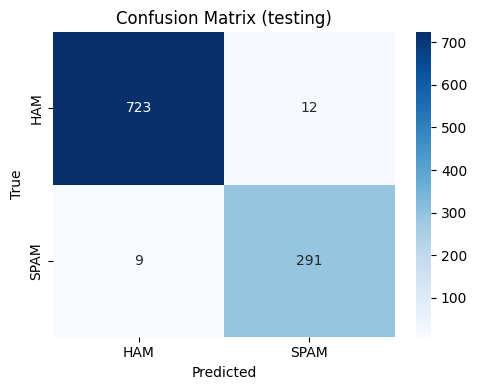

In [39]:
classification_report_function(mlp_model, X_train_tfidf_array, y_train, X_test_tfidf_array, y_test, threshold=0.7, NN=True)

Il MultiLayer Perceptron mostra prestazioni nettamente superiori rispetto al modello Naive-Bayes testato in precedenza.

Sul training set, il modello raggiunge praticamente la perfezione: accuratezza del 100%, precision e recall altissime per entrambe le classi.

Sul testing set, il modello mantiene comunque un’ottima generalizzazione: accuratezza del 98%, precision del 96% sulla classe SPAM e recall del 97%, con una riduzione significativa degli errori rispetto al Naive Bayes. La confusion matrix conferma che sia i falsi positivi sia i falsi negativi sono molto contenuti.

L’andamento delle epoche mostra una rapida convergenza: già dalla prima epoca la val_accuracy raggiunge il 97% e l’early stopping interviene per evitare sovra-allenamento.

Per concludere, il MLP risulta essere il modello più performante, con un eccellente capacità di discriminare tra mail HAM e SPAM .


## Topic Modelling

Il secondo obiettivo del progetto consiste nell’identificare i principali topic presenti nelle mail SPAM.

Per farlo affrontiamo un’operazione di Topic Modelling, che può essere svolta mediante l’algoritmo **LDA** (Latent Dirichlet Allocation).

In [40]:
spam_texts = df.loc[df["label_num"] == 1, "text"]
spam_texts.head()

,text
3,"Subject: photoshop , windows , office . cheap ..."
7,Subject: looking for medication ? we ` re the ...
10,Subject: vocable % rnd - word asceticism\nvcsc...
11,Subject: report 01405 !\nwffur attion brom est...
13,Subject: vic . odin n ^ ow\nberne hotbox carna...


In [41]:
spam_tokens = spam_texts.apply(topic_cleaner)
spam_tokens.head()

,text
3,"[photoshop, window, office, cheap, main, trend..."
7,"[look, medication, good, source, difficult, ma..."
10,"[vocable, rnd, word, asceticism, vcsc, brand, ..."
11,"[report, wffur, attion, brom, est, inst, siupi..."
13,"[vic, odin, berne, hotbox, carnal, bride, cutw..."


Una volta selezionate le mail SPAM, applichiamo la fase di pulizia e convertiamo ciascun messaggio in un insieme di token, in questo modo ogni mail viene rappresentata come una lista di parole.

In [42]:
# Create dictionary for LDA
dictionary = corpora.Dictionary(spam_tokens)

# Create the corpus for LDA (Bag of Words)
corpus = [dictionary.doc2bow(tokens) for tokens in spam_tokens]

Per applicare LDA utilizziamo la rappresentazione Bag-of-Words generata tramite la vettorizzazione del modulo corpora, analoga a quella ottenuta con CountVectorizer.

In [43]:
NUM_TOPICS = 5

In [44]:
# LDA
lda_model = gensim.models.LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=RANDOM_SEED,
    passes=10
)

doc_lda = lda_model[corpus]

In [45]:
for i, topic in lda_model.print_topics():
    print(f"\nTopic {i + 1}:\n")
    print(topic)
    print("-" * 40)


Topic 1:

0.015*"company" + 0.009*"statement" + 0.008*"stock" + 0.006*"information" + 0.005*"report" + 0.005*"investment" + 0.005*"security" + 0.005*"price" + 0.004*"inc" + 0.004*"look"
----------------------------------------

Topic 2:

0.005*"com" + 0.003*"good" + 0.003*"soft" + 0.003*"cialis" + 0.003*"new" + 0.003*"want" + 0.003*"email" + 0.002*"tab" + 0.002*"save" + 0.002*"hour"
----------------------------------------

Topic 3:

0.010*"com" + 0.006*"contact" + 0.005*"computron" + 0.005*"email" + 0.005*"message" + 0.005*"send" + 0.005*"account" + 0.004*"remove" + 0.004*"mail" + 0.004*"free"
----------------------------------------

Topic 4:

0.008*"pill" + 0.007*"price" + 0.005*"font" + 0.005*"com" + 0.004*"adobe" + 0.004*"color" + 0.004*"software" + 0.004*"good" + 0.004*"professional" + 0.003*"office"
----------------------------------------

Topic 5:

0.014*"nbsp" + 0.014*"height" + 0.013*"font" + 0.011*"width" + 0.007*"border" + 0.006*"com" + 0.006*"src" + 0.006*"href" + 0.006*

Procediamo ora a stimare la distanza semantica tra i topic individuati nelle mail SPAM, con l’obiettivo di valutarne il grado di eterogeneità.

Per prima cosa vettorizziamo i testi ed eseguiamo un embedding in uno spazio vettoriale, in cui parole e documenti sono rappresentati da vettori tali che contenuti simili risultino geometricamente più vicini. Come misura di distanza utilizziamo la cosine similarity.

Per confrontare i topic possiamo mediare i vettori delle parole più rappresentative, creando un vettore che sintetizzi ciascun topic.

Infine, per ogni topic prodotto da LDA estraiamo le parole chiave più rilevanti e le raggruppiamo in una lista complessiva.

In [46]:
# Show the top10 words of topic 3
topic = lda_model.show_topic(3, topn=10)

for word, weight in topic:
    print(f"{word:10}  {float(weight):.4f}")

pill        0.0084
price       0.0071
font        0.0050
com         0.0049
adobe       0.0044
color       0.0041
software    0.0040
good        0.0037
professional  0.0035
office      0.0034


L’elenco mostra le dieci parole più rappresentative del Topic 3, ordinate per peso all’interno del modello LDA.

In [47]:
topics_keywords = []
for topic_id in range(NUM_TOPICS):
    words = [w for w, _ in lda_model.show_topic(topic_id, topn=10)]
    topics_keywords.append(words)

for i, words in enumerate(topics_keywords):
    print(f"\nTopic {i}:")
    print(", ".join(words))


Topic 0:
company, statement, stock, information, report, investment, security, price, inc, look

Topic 1:
com, good, soft, cialis, new, want, email, tab, save, hour

Topic 2:
com, contact, computron, email, message, send, account, remove, mail, free

Topic 3:
pill, price, font, com, adobe, color, software, good, professional, office

Topic 4:
nbsp, height, font, width, border, com, src, href, align, size


L’estrazione delle dieci parole chiave per ciascun topic permette di rappresentare in modo sintetico i contenuti individuati dal modello LDA.

I topic emersi mostrano gruppi di termini coerenti:

- Topic 0: vocaboli legati a finanza ed investimenti;
- Topic 1: parole tipiche di spam promozionale su prodotti farmaceutici e offerte commerciali;
- Topic 2: riferimenti a comunicazioni mail, contatti, gestione account e richieste di rimozione;
- Topic 3: combinazione di termini relativi a pillole e prodotti software, con elementi di formattazione HTML;
- Topic 4: quasi esclusivamente parole legate a markup e strutture HTML.

Questa classificazione evidenzia come lo spam del dataset sia eterogeneo e riconducibile a diverse categorie tematiche.

In [48]:
# Mean vector for each topic
topic_vectors = [avg_topic_vector(topic, glove_model) for topic in topics_keywords]

print(len(topic_vectors))
print(len(topic_vectors[0]))

5
300


In [49]:
topic_labels = [f"Topic {i}" for i in range(NUM_TOPICS)]

distance_matrix = np.zeros((NUM_TOPICS, NUM_TOPICS), dtype=float)

for i in range(NUM_TOPICS):
    for j in range(NUM_TOPICS):
        if i != j:
            distance_matrix[i, j] = cosine(topic_vectors[i], topic_vectors[j])

similarity_matrix = 1 - distance_matrix

sim_df = pd.DataFrame(similarity_matrix,
                      index=topic_labels,
                      columns=topic_labels)

print("Topic Similarity Matrix\n")
print(sim_df.round(3))

Topic Similarity Matrix

         Topic 0  Topic 1  Topic 2  Topic 3  Topic 4
Topic 0    1.000    0.575    0.502    0.594    0.236
Topic 1    0.575    1.000    0.706    0.674    0.376
Topic 2    0.502    0.706    1.000    0.496    0.231
Topic 3    0.594    0.674    0.496    1.000    0.483
Topic 4    0.236    0.376    0.231    0.483    1.000


La matrice di similarità mostra quanto ogni topic sia semanticamente vicino agli altri sulla base dei vettori medi dei termini rappresentativi.

I Topic 0, 1, 2 e 3 presentano valori di similarità relativamente buoni tra loro (compresi tra 0.50 e 0.70), indicando che condividono contenuti parzialmente sovrapposti: si tratta infatti di spam legato a temi commerciali, prodotti, comunicazioni mail o software.

Il Topic 4, invece, risulta nettamente più distante dagli altri (similarità tra 0.23 e 0.48). Questo conferma che il contenuto basato su markup HTML rappresenta una categoria distinta rispetto agli altri gruppi tematici.

In sintesi, lo spam appare composto da quattro topic moderatamente correlati e da un quinto topic più eterogeneo e separato dal resto.

## Estrazione organizzazioni

Per estrarre i nomi delle organizzazioni dalle mail ham possiamo utilizzare tecniche di **Named Entity Recognition** (NER).

In [50]:
df_ham = df.loc[df["label_num"] == 0]
df_ham.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0
5,2949,ham,Subject: ehronline web address change\nthis me...,0


In [51]:
ham_texts = df_ham["text"]

Effettuiamo una pulizia del testo meno invasiva rispetto a quella utilizzata per la classificazione, preservando la struttura linguistica utile per il NER.

In [52]:
ham_texts = df_ham["text"].apply(ner_cleaner)

In [53]:
EXCLUDE_TERMS = {
    "email", "account", "service", "please",
    "message", "price", "subject",
    "xls", "doc", "pdf", "msg"
}

orgs = []

for mail in ham_texts:
  doc = nlp(mail)
  for ent in doc.ents:
    if ent.label_ == "ORG":
            ent_clean = ent.text.strip().lower()

            if not ent_clean or len(ent_clean) <= 2:
                continue

            if ent_clean in EXCLUDE_TERMS:
                continue

            orgs.append(ent_clean)

In [54]:
print(len(orgs))

14680


Sono state individuate 14.680 organizzazioni

In [55]:
# Count the most mentioned organizations
org_counts = Counter(orgs)
top10_orgs = org_counts.most_common(10)
org_df = pd.DataFrame(top10_orgs, columns=["Organization", "Frequency"])

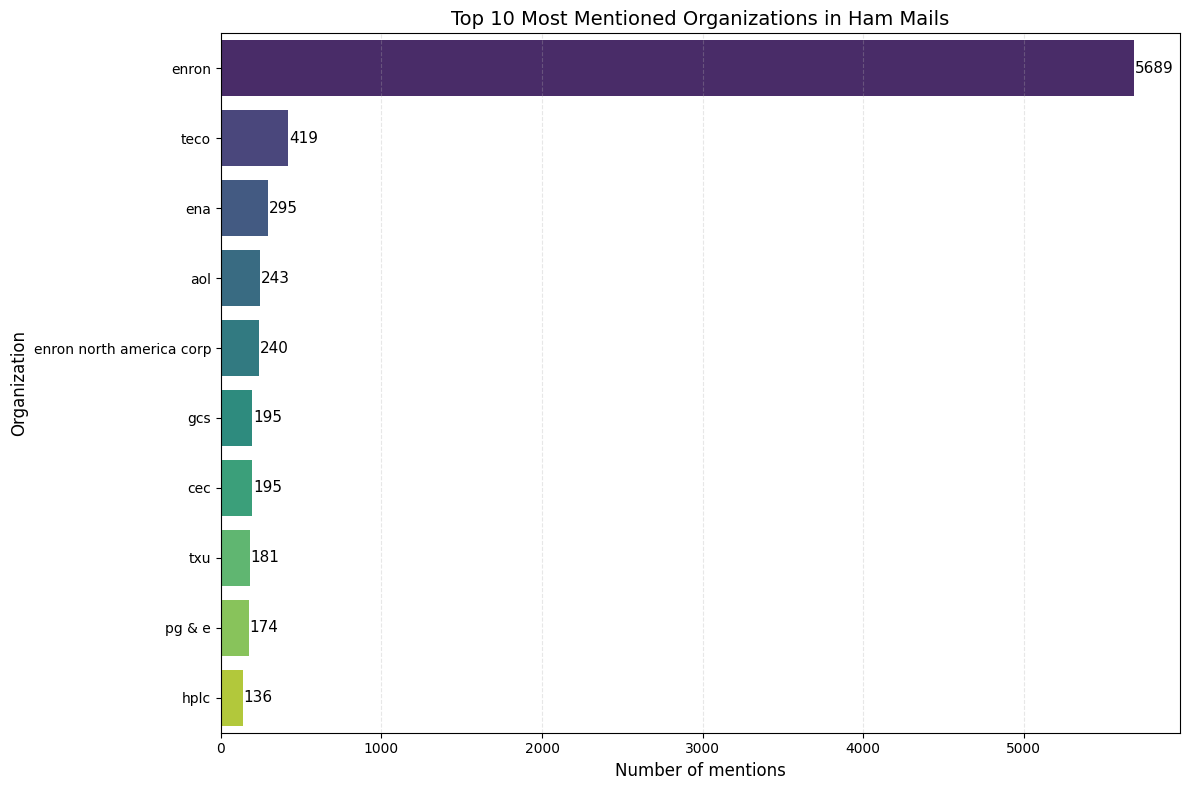

In [57]:
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=org_df,
    x="Frequency",
    y="Organization",
    palette="viridis"
)

for p in ax.patches:
    value = int(p.get_width())
    y_pos = p.get_y() + p.get_height() / 2
    ax.text(p.get_width() + 5, y_pos, value, va='center', fontsize=11)

plt.xlabel("Number of mentions", fontsize=12)
plt.ylabel("Organization", fontsize=12)
plt.title("Top 10 Most Mentioned Organizations in Ham Mails", fontsize=14)

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Il grafico mostra le dieci organizzazioni più frequentemente menzionate nelle mail HAM.

Enron domina in modo assoluto, con un numero di citazioni di gran lunga superiore rispetto alle altre entità. Le restanti organizzazioni come Teco, ENA, AOL e Enron North America Corp, compaiono con frequenze molto più contenute ma comunque significative. La distribuzione evidenzia un ecosistema comunicativo concentrato su un gruppo ristretto di attori, principalmente aziende del settore energetico e partner operativi.